In [1]:
import pandas as pd

train = pd.read_parquet("data/processed/notebook3_train.parquet")
print(train.shape)

(67529, 18)


In [2]:
train.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,n_items,total_price,total_freight,total_payment,n_payments,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,label
0,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,3.0,134.97,8.49,NaN,NaN,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,Late
1,3b697a20d9e427646d92567910af6d57,355077684019f7f60a031656bd7262b8,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,2016-10-26 14:02:13,2016-10-27,1.0,29.90,15.56,45.46,1.0,32ea3bdedab835c3aa6cb68ce66565ef,4106,sao paulo,SP,On-time
2,be5bc2f0da14d8071e2d45451ad119d9,7ec40b22510fdbea1b08921dd39e63d8,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,2016-10-27 18:19:38,2016-11-07,1.0,21.90,17.19,39.09,1.0,2f64e403852e6893ae37485d5fcacdaf,98280,panambi,RS,On-time
3,a41c8759fbe7aab36ea07e038b2d4465,6f989332712d3222b6571b1cf5b835ce,delivered,2016-10-03 21:13:36,2016-10-05 03:11:49,2016-10-25 11:57:59,2016-11-03 10:58:07,2016-11-29,1.0,36.49,17.24,53.73,1.0,61db744d2f835035a5625b59350c6b63,90040,porto alegre,RS,On-time
4,d207cc272675637bfed0062edffd0818,b8cf418e97ae795672d326288dfab7a7,delivered,2016-10-03 22:06:03,2016-10-04 10:28:07,2016-10-21 14:23:37,2016-10-31 11:07:42,2016-11-23,1.0,119.90,13.56,133.46,1.0,8d3a54507421dbd2ce0a1d58046826e0,13185,hortolandia,SP,On-time


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 67529 entries, 0 to 67528
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       67529 non-null  str           
 1   customer_id                    67529 non-null  str           
 2   order_status                   67529 non-null  str           
 3   order_purchase_timestamp       67529 non-null  datetime64[us]
 4   order_approved_at              67515 non-null  datetime64[us]
 5   order_delivered_carrier_date   67528 non-null  datetime64[us]
 6   order_delivered_customer_date  67529 non-null  datetime64[us]
 7   order_estimated_delivery_date  67529 non-null  datetime64[us]
 8   n_items                        67529 non-null  float64       
 9   total_price                    67529 non-null  float64       
 10  total_freight                  67529 non-null  float64       
 11  total_payment             

In [4]:
id_cols = ["order_id", "customer_id", "customer_unique_id"]
categorical_features = ["customer_state", "customer_city"]
numeric_features = ["n_items", "total_price", "total_freight", "total_payment", "n_payments"]
date_cols_all = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", 
                 "order_delivered_customer_date", "order_estimated_delivery_date"]

print("ID columns (Don't use as features ):", id_cols)
print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)
print("Date columns:", date_cols_all)

ID columns (Don't use as features ): ['order_id', 'customer_id', 'customer_unique_id']
Categorical features: ['customer_state', 'customer_city']
Numeric features: ['n_items', 'total_price', 'total_freight', 'total_payment', 'n_payments']
Date columns: ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [5]:
train.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,n_items,total_price,total_freight,total_payment,n_payments
count,67529,67515,67528,67529,67529,67529.000000,67529.000000,67529.000000,67528.000000,67528.000000
mean,2017-10-21 00:36:43.410697,2017-10-21 11:46:53.039991,2017-10-24 11:51:14.791242,2017-11-03 20:23:35.785144,2017-11-14 14:53:53.277554,1.142072,135.888797,22.245936,158.173637,1.047625
min,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1.000000,2.290000,0.000000,10.070000,1.000000
25%,2017-07-22 15:11:48,2017-07-22 22:50:14.500000,2017-07-26 10:17:43,2017-08-02 20:34:52,2017-08-15 00:00:00,1.000000,45.900000,14.100000,61.630000,1.000000
50%,2017-11-18 23:10:58,2017-11-19 15:10:34,2017-11-22 17:38:40.500000,2017-11-30 16:00:09,2017-12-11 00:00:00,1.000000,85.000000,16.790000,104.190000,1.000000
75%,2018-01-31 16:08:33,2018-02-01 02:52:52,2018-02-05 13:20:15.500000,2018-02-16 16:58:53,2018-03-01 00:00:00,1.000000,149.900000,23.700000,175.500000,1.000000
max,2018-04-15 20:12:35,2018-04-24 18:04:50,2018-05-08 14:04:00,2018-09-19 23:24:07,2018-08-03 00:00:00,21.000000,13440.000000,1002.290000,13664.080000,26.000000
std,NaN,NaN,NaN,NaN,NaN,0.541640,205.194019,20.002594,214.285757,0.397223


**النتائج**

1. **Missing values:** قليلة جدًا (أقل من 0.03%) بأعمدة `order_approved_at`, `order_delivered_carrier_date`, `total_payment`, `n_payments` — غير مقلقة، والقرار بالتعامل معها هيتأجل لـ **Notebook 5**.

2. **Outliers محتملة:** في `total_price` (وسيط 85 مقابل أقصى 13,440) و`total_freight` (وسيط 16.79 مقابل أقصى 1,002.29) — لازم نتفحصها بصريًا باستخدام **boxplot**.

3. **n_items:** أغلب الطلبيات منتج واحد (وسيط 1)، ونادرًا توصل لـ 21 منتج.

4. **n_payments:** أغلب الطلبيات دفعة واحدة، ونادرًا توصل لـ 26 دفعة.

5. **المدى الزمني للـ train:** من `2016-09-15` إلى `2018-04-15`، ومتسق مع **Notebook 3**.


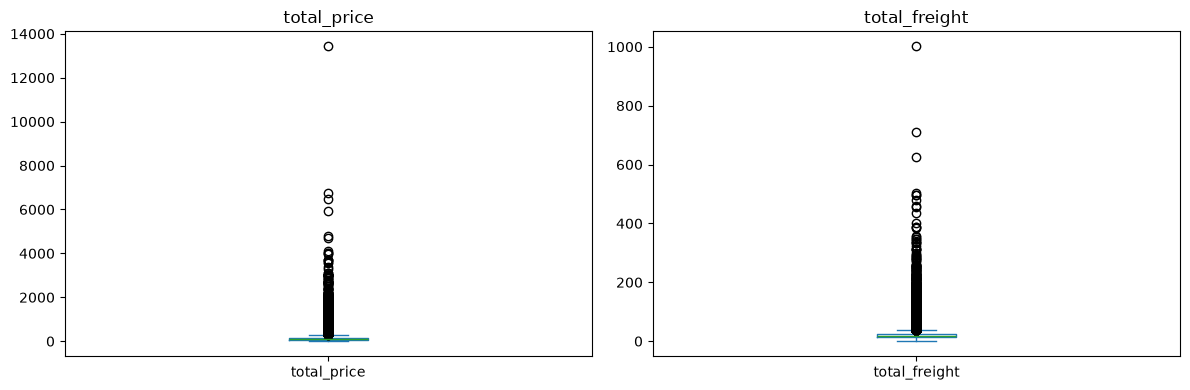

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train["total_price"].plot(kind="box", ax=axes[0], title="total_price")
train["total_freight"].plot(kind="box", ax=axes[1], title="total_freight")
plt.tight_layout()
plt.show()

. Outliers مؤكدة بصريًا (boxplot) في total_price و total_freight:
   - أغلب القيم قريبة من الصفر لغاية ~500 (price) و ~50 (freight)
   - نقاط متطرفة نادرة توصل لـ 13,440 (price) و 1,002 (freight)
   - قرار المعالجة (RobustScaler / log-transform / ترك كما هو) 
     هيتأجل لـ Notebook 5، هون بس توثيق الملاحظة.

In [ ]:
train.groupby("label")[["total_price", "total_freight", "n_items"]].mean()

,total_price,total_freight,n_items
label,,,
Late,149.787024,25.204762,1.114337
On-time,134.509675,21.952332,1.144824


. العلاقة بين الأعمدة الرقمية والـ label:
   - الطلبيات المتأخرة (Late) عندها متوسط total_price أعلى (149.79 
     مقابل 134.51) ومتوسط total_freight أعلى (25.20 مقابل 21.95) من 
     الطلبيات On-time.
   - الفرق بـ n_items غير ملحوظ (1.114 مقابل 1.145).
   - تفسير محتمل: طلبيات أغلى/أثقل قد تحتاج شحن أعقد فتتأخر أكتر — 
     هاد (correlation) مش دليل (causation) مؤكدة.

In [ ]:
train["is_late"] = (train["label"] == "Late")
state_late_rate = train.groupby("customer_state")["is_late"].mean()
state_late_rate.sort_values(ascending=False).head(10)

customer_state
AL    0.278523
MA    0.215328
CE    0.182489
RR    0.172414
SE    0.170732
PI    0.166667
RJ    0.165867
BA    0.149978
PA    0.133705
ES    0.132872
Name: is_late, dtype: float64

. تحليل جغرافي (customer_state) — فروقات كبيرة بنسبة التأخير:
   - أعلى نسبة تأخير: AL (27.9%), MA (21.5%), CE (18.2%)
   - هاد أعلى بكثير من المعدل العام (~9%)
   - نمط واضح: أغلب الولايات ذات نسبة التأخير الأعلى تقع بشمال/شمال شرق 
     البرازيل — أبعد جغرافيًا عن المراكز اللوجستية الرئيسية.
   - استثناء ملحوظ: RJ (ريو دي جانيرو) موجودة بالقائمة رغم كونها منطقة 
     مركزية — يستاهل فحص إضافي.
   - هاد يشير إنو "الموقع الجغرافي" ممكن يكون feature قوي ومهم 
     لـ Notebook 5 (feature engineering).

In [ ]:
pd.crosstab(train["customer_state"], train["label"], normalize="index").head(10)

label,Late,On-time
customer_state,,
AC,0.045455,0.954545
AL,0.278523,0.721477
AM,0.047619,0.952381
AP,0.058824,0.941176
BA,0.149978,0.850022
CE,0.182489,0.817511
DF,0.079772,0.920228
ES,0.132872,0.867128
GO,0.095813,0.904187


. Crosstab شامل (customer_state × label):


    - جدول كامل يعرض نسبة Late وOn-time جنب بعض لكل ولاية (بدل عمود 
      Late المنفرد فقط).
    - النتائج مطابقة تمامًا للتحليل السابق (state_late_rate) — AL 
      أعلى نسبة تأخير (27.85%)، يليها MA (21.53%) وCE (18.25%).
    - ملاحظة إضافية: الولايات ذات أقل نسبة تأخير (AC: 4.55%, AM: 4.76%) 
      هي أيضًا من الولايات صغيرة العينة (AC=66 صف, AM=105 صف) — 
      نفس تحذير "الحذر من العينات الصغيرة" اللي انطبق على RR سابقًا 
      ينطبق هون كمان، بالاتجاه المعاكس.

<Axes: title={'center': 'Late rate by month'}, xlabel='purchase_month'>

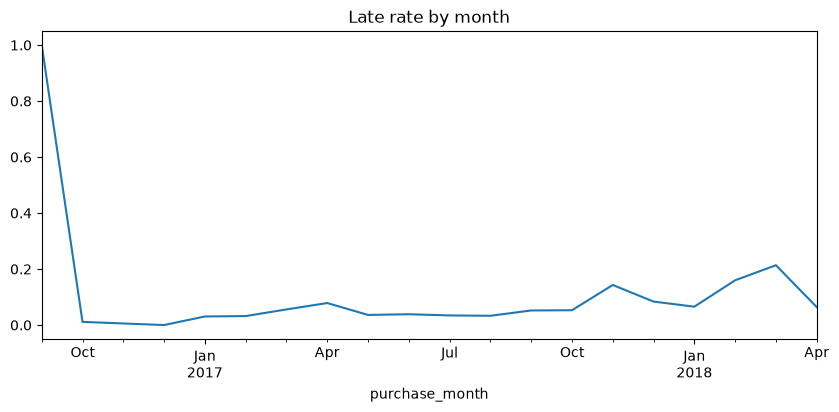

In [ ]:
train["purchase_month"] = train["order_purchase_timestamp"].dt.to_period("M")
train.groupby("purchase_month")["is_late"].mean().plot(kind="line", figsize=(10, 4), title="Late rate by month")

. تحليل زمني شهري (purchase_month vs is_late):
   - أول نقطة (سبتمبر 2016) نسبة تأخير ~100% — على الأغلب ضجيج إحصائي 
     بسبب حجم عينة صغير جدًا (بداية جمع البيانات)، لازم نتأكد بعدد الطلبيات.
   - من أكتوبر 2016 لنوفمبر 2017: نسبة تأخير مستقرة نسبيًا (~0-8%)
   - من ديسمبر 2017 لمارس 2018: ارتفاع تدريجي وصل لـ ~22% — يفسر 
     الفرق بنسبة Late بين train/val/test اللي لاحظناه بـ Notebook 3.
   - احتمال وجود تأثير موسمي (نهاية السنة/بداية 2018) على جودة التوصيل.

In [ ]:
train.groupby("purchase_month")["is_late"].agg(["mean", "count"]).head(5)

,mean,count
purchase_month,,
2016-09,1.000000,1
2016-10,0.011321,265
2016-12,0.000000,1
2017-01,0.030667,750
2017-02,0.032063,1653


. تحليل زمني شهري (purchase_month vs is_late) - محدّث:
   - أول شهر (2016-09) فيه طلبية واحدة بس (n=1) → نسبة 100% تأخير 
     غير ممثلة إحصائيًا، مجرد ضجيج بسبب حجم عينة صغير جدًا.
   - نفس المشكلة بشهر 2016-12 (n=1، نسبة 0%).
   - من 2016-09 إلى ~2016-12: فترة "bootstrap" (انطلاق المنصة)، عدد 
     طلبيات ضئيل جدًا وغير مستقر — لا يمثل السلوك الحقيقي للمنصة.
   - القرار: لا حذف لأي بيانات فعلية، بس نتجاهل هاي الفترة بصريًا فقط 
     عند عرض الرسوم البيانية لاحقًا (نبلش من أكتوبر 2016 فما فوق).
   - من 2017 فصاعدًا: البيانات مستقرة وممثلة إحصائيًا (750+ طلبية شهريًا).
   - الاتجاه التصاعدي بنسبة Late من ديسمبر 2017 لمارس 2018 يبقى ملاحظة 
     حقيقية ومهمة (غير متأثرة بمشكلة العينة الصغيرة).

In [ ]:
missing = train.isnull().sum()
missing = missing[missing > 0]
print(missing)

order_approved_at               14
order_delivered_carrier_date     1
total_payment                    1
n_payments                       1
dtype: int64


. القيم الناقصة (missing values) بالتفصيل:

    - order_approved_at: 14 صف ناقص
    - order_delivered_carrier_date: 1 صف ناقص
    - total_payment: 1 صف ناقص
    - n_payments: 1 صف ناقص
    - كلها أعداد ضئيلة جدًا (أقل من 0.03% من البيانات) — غير مقلقة إطلاقًا.
    - القرار بالتعامل معها (حذف الصفوف / تعبئة بقيمة) هيتأجل لـ Notebook 5 
      (feature engineering)، لأنها مش جزء من الـ label نفسه.

In [ ]:
train["missing_approved_at"] = train["order_approved_at"].isnull()
train.groupby("missing_approved_at")["is_late"].mean()

missing_approved_at
False    0.090291
True     0.000000
Name: is_late, dtype: float64

### فحص "missingness" كإشارة محتملة (`order_approved_at`)

* الطلبيات اللي ناقصها `order_approved_at` (14 صف) كلها **On-time** (0.00% Late)، بينما باقي الطلبيات عندها نسبة **Late = 9.03%**.

* العينة صغيرة جدًا جدًا (14 صف بس من أصل 67,529)، فممكن تكون النتيجة مجرد صدفة إحصائية، ومش نمط حقيقي وموثوق.

* ما بنقدر نستنتج بثقة إنو **غياب `order_approved_at` مرتبط بعدم التأخير** بناءً على عينة صغيرة لهالدرجة.

### القرار

بنخليها **ملاحظة استكشافية فقط**، بدون ما نعتمد عليها كاستنتاج قوي.

ولو بدنا نستخدم `missing_approved_at` كـ **feature** بـ Notebook 5، لازم نكون حذرين جدًا بسبب صغر حجم العينة.


In [ ]:
categorical_cols = ["order_status", "customer_state", "customer_city"]

for col in categorical_cols:
    print(f"--- {col} ---")
    print("unique values:", train[col].nunique())
    print(train[col].value_counts().head(5))
    print()

--- order_status ---
unique values: 1
order_status
delivered    67529
Name: count, dtype: int64

--- customer_state ---
unique values: 27
customer_state
SP    27204
RJ     8965
MG     8129
RS     3912
PR     3461
Name: count, dtype: int64

--- customer_city ---
unique values: 3747
customer_city
sao paulo         9920
rio de janeiro    4777
belo horizonte    1869
brasilia          1395
curitiba          1020
Name: count, dtype: int64



In [ ]:
sample_cities = train["customer_city"].unique()
print("number of unique cities:", len(sample_cities))
print(sorted(sample_cities)[:20])

number of unique cities: 3747
['abadia dos dourados', 'abadiania', 'abaete', 'abaetetuba', 'abaiara', 'abare', 'abatia', 'abdon batista', 'abelardo luz', 'abrantes', 'abre campo', 'abreu e lima', 'acaiaca', 'acailandia', 'acarau', 'acegua', 'acopiara', 'acreuna', 'acu', 'acucena']


### فحص `customer_city`

* العمود فيه **3,747 مدينة فريدة**.
* فحصت أول 20 اسم بالترتيب الأبجدي، والبيانات طلعت **نظيفة ومتسقة**.
* كل الأسماء بحروف صغيرة، وما لقيت تضارب بين أشكال مختلفة لنفس الاسم (زي `"sao paulo"` و`"Sao Paulo"`).
* ما لاحظت أي مشكلة تنسيق واضحة أو تكرار فئات وهمي.

> الفحص كان بصري سريع لعينة فقط، مش تحقق شامل لكل الـ **3,747** قيمة، لكنه أعطى مؤشر منيح إنو العمود منسّق كويس.


In [ ]:
train[train["order_status"] == "canceled"][["order_id", "order_status", "order_delivered_customer_date", "order_estimated_delivery_date", "label"]]
#فحص الطلبيات يلي انلغو

,order_id,order_status,order_delivered_customer_date,order_estimated_delivery_date,label


### 1. أثناء فحص الأعمدة categorical بـ Notebook 4

لاحظت وجود **6 طلبيات (0.009%)** حالتها `"canceled"` رغم إنو عندها `order_delivered_customer_date` فعلي — وهاد تناقض منطقي واضح، لأنو طلبية ملغاة المفروض ما توصل للزبون أصلاً. لاحظت كمان إنو **5 من أصل الـ 6** كانت من فترة أكتوبر-نوفمبر 2016 (فترة الـ "bootstrap" المبكرة لجمع البيانات).

### 2. مكان معالجة المشكلة

هاد الاكتشاف صار متأخر (بـ Notebook 4)، بس المكان الصحيح لمعالجته منهجيًا هو **Notebook 2** — لحظة بناء الـ label نفسها — لأنو label لطلبية ملغاة غير موثوق ومش لازم يدخل بالتحليل أصلاً.

### 3. التعديل بـ Notebook 2

رجعت لـ Notebook 2 وأضفت فلتر يستبعد الطلبيات اللي حالتها `"canceled"` قبل بناء عمود الـ label. هاد مثال عملي على قيمة مراجعة البيانات بعمق أثناء الـ EDA، حتى لو الخطوات السابقة بدت مكتملة ونظيفة.

### 4. إعادة تشغيل الـ Notebooks

بما إنو Notebook 3 وNotebook 4 مبنيين على artifact مباشر من Notebook 2، أعدت تشغيلهم بالكامل من الأول (**Notebook 2 → 3 → 4**) عشان كل الأرقام والنسب والرسوم تنبني على النسخة النظيفة والمحدّثة من البيانات — تطبيق فعلي لمبدأ **artifact-based flow**.

### 5. النتيجة بعد التصحيح

بعد التصحيح، فحصت `order_status` من جديد بـ Notebook 4 المحدّث، وطلع:

`order_status` هسه قيمة واحدة بس: `"delivered"` (**67,529 صف بالكامل**).

الطلبيات الملغاة اختفت تمامًا من `train` — دليل مباشر إنو الفلتر اشتغل صح، وانتشر تأثيره تلقائيًا عبر السلسلة كاملة (**Notebook 2 → 3 → 4**).


In [ ]:
train["delivery_duration"] = (train["order_delivered_customer_date"] - train["order_purchase_timestamp"]).dt.days

train["delivery_duration"].describe()

count    67529.000000
mean        13.355995
std         10.256213
min          0.000000
25%          7.000000
50%         11.000000
75%         17.000000
max        209.000000
Name: delivery_duration, dtype: float64

### مدة التوصيل (`delivery_duration`) - إحصائيات عامة

* **Mean:** 13.36 يوم | **Median:** 11 يوم

* **Range:** من 0 يوم (توصيل بنفس يوم الشراء) لغاية 209 يوم (~7 شهور!)

* **Maximum value** (209 يوم) غير منطقية جدًا وتتسق مع نمط الـ **outliers** اللي شفناه بـ `total_price`/`total_freight` — يحتمل تكون نفس الطلبيات المتطرفة ظاهرة بعدة أبعاد مع بعض.

* `min = 0` (مش قيمة سالبة) — إشارة جيدة إنو لا يوجد خطأ منطقي أساسي بترتيب التواريخ.


In [ ]:
train.groupby("label")["delivery_duration"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Late,6096.0,34.047080,16.963569,7.0,25.0,31.0,39.0,209.0
On-time,61433.0,11.302818,6.354433,0.0,7.0,10.0,15.0,70.0


## مدة التوصيل (delivery_duration) مقابل label - اكتشاف قوي + تحذير

* Late: متوسط 34.05 يوم | الوسيط 31 يوم | أدنى 7 يوم | أقصى 209 يوم
* On-time: متوسط 11.30 يوم | الوسيط 10 يوم | أدنى 0 يوم | أقصى 70 يوم
* فرق كبير جدًا وواضح بين الفئتين، بدون أي تداخل بالحد الأدنى  
  (Late لا تقل عن 7 أيام، بينما On-time تبدأ من 0).

### تحذير حرج (Data Leakage)

delivery_duration محسوب من order_delivered_customer_date — نفس  
العمود المستخدم لبناء label بـ Notebook 2. وقت التنبؤ الفعلي  
(لحظة الشراء)، ما منعرف متى رح توصل الطلبية أصلاً — فاستخدام  
delivery_duration كـ feature بالموديل بيكون تسريب بيانات مباشر  
(الموديل "بيغش" بمعلومة من المستقبل).

### القرار

delivery_duration مفيد جدًا للاستكشاف والفهم (EDA)، لكن  
يجب استبعاده بشكل قاطع من قائمة الـ features بـ Notebook 5. أي  
عمود مبني من order_delivered_customer_date أو order_estimated_delivery_date  
(بعد لحظة الشراء) يحمل نفس الخطر ولازم يُستبعد.

In [ ]:
train["purchase_dayofweek"] = train["order_purchase_timestamp"].dt.day_name()

train.groupby("purchase_dayofweek")["is_late"].mean().sort_values(ascending=False)

purchase_dayofweek
Monday       0.100149
Friday       0.094699
Tuesday      0.092646
Saturday     0.089688
Wednesday    0.086082
Sunday       0.083808
Thursday     0.082859
Name: is_late, dtype: float64

### تأثير يوم الأسبوع (`purchase_dayofweek`) على نسبة التأخير

* أعلى نسبة: Monday (10.01%) | أقل نسبة: Thursday (8.29%)

* الفرق بين أعلى وأقل نسبة صغير جدًا (~1.7 نقطة مئوية) مقارنة بعوامل تانية (زي الجغرافيا أو `delivery_duration`).

* لا يوجد نمط واضح "نهاية أسبوع مقابل أيام عمل" — Saturday/Sunday مش أعلى نسبة كما هو متوقع.

* الخلاصة: يوم الأسبوع عامل ضعيف التأثير نسبيًا، احتمال يكون feature بأولوية منخفضة مقارنة بعوامل تانية أقوى (الموقع الجغرافي، الموسمية الشهرية).

In [ ]:
train["is_holiday_season"] = train["order_purchase_timestamp"].dt.month.isin([11, 12])
train.groupby("is_holiday_season")["is_late"].mean()

is_holiday_season
False    0.083889
True     0.117560
Name: is_late, dtype: float64

### تأثير موسم الأعياد (نوفمبر وديسمبر)

- نسبة التأخير بموسم الأعياد (نوفمبر/ديسمبر): **11.76%**

- نسبة التأخير بباقي الشهور: **8.39%**

- فرق واضح (~3.4 نقطة مئوية) — أكبر بكثير من فرق يوم الأسبوع  
  (~1.7 نقطة مئوية)، مما يجعل الموسمية عامل أقوى تأثيرًا.

- يتسق هذا مع الاتجاه التصاعدي اللي لوحظ بالتحليل الشهري (ارتفاع  
  نسبة Late من ديسمبر 2017 لمارس 2018) — على الأغلب بسبب ضغط  
  الطلبات (Black Friday، الكريسماس) على المستودعات وشركات الشحن.

- القرار لـ Notebook 5: `is_holiday_season` (أو `purchase_month`  
  بشكل عام) يستاهل يكون feature بأولوية عالية نسبيًا، أعلى من يوم الأسبوع.

In [ ]:
print("unique zip codes:", train["customer_zip_code_prefix"].nunique())
train["customer_zip_code_prefix"].value_counts().head(10)

unique zip codes: 13748


customer_zip_code_prefix
22790    113
22793     89
24220     82
24230     81
22775     80
29101     73
35162     69
22631     64
37200     63
35500     62
Name: count, dtype: int64

In [ ]:
train["customer_state"].value_counts().tail(10)

customer_state
RN    349
PI    348
AL    298
SE    246
TO    197
RO    185
AM    105
AC     66
AP     51
RR     29
Name: count, dtype: int64

### (`customer_zip_code_prefix`)

- 13,748 قيمة فريدة — عدد كبير جدًا وغير عملي كـ feature تصنيفي مباشر (one-hot encoding مستحيل عمليًا، overfitting شبه مؤكد).

- أعلى تكرار (22790) عنده بس 113 صف — كل zip code يمثل جزء ضئيل جدًا من البيانات.

- الاستخدام الأنسب: كمصدر لحساب إحداثيات جغرافية (عبر جدول geolocation)، أو تجميعه لمناطق أوسع، مش استخدامه كما هو.

### الفئات النادرة بـ `customer_state`

- RR (رورايما) عندها 29 صف بس، AP عندها 51 صف، AC عندها 66 صف.

- RR كانت من أعلى الولايات بنسبة تأخير (17.2%) بتحليل سابق — بس بما إنو العينة صغيرة جدًا (29 صف)، هاي النسبة قد تكون غير موثوقة إحصائيًا (يمكن صدفة، مش نمط حقيقي).

- في Notebook 5: التفكير بتجميع الولايات ذات العدد القليل جدًا (< 100 صف مثلاً) بفئة "أخرى" (Other) بدل الاحتفاظ بكل ولاية لحالها، لتقليل تأثير الضجيج الإحصائي من العينات الصغيرة.

In [ ]:
numeric_cols = ["n_items", "total_price", "total_freight", "total_payment", "n_payments", "delivery_duration"]
train[numeric_cols].skew()

n_items               8.107162
total_price          10.718895
total_freight         8.581743
total_payment        10.149318
n_payments           22.419509
delivery_duration     3.862791
dtype: float64

### تحليل الالتواء (Skewness) للأعمدة الرقمية

- `n_items`: 8.11 | `total_price`: 10.72 | `total_freight`: 8.58 | `total_payment`: 10.15 | `n_payments`: 22.42 | `delivery_duration`: 3.86

- كل الأعمدة عندها skew أعلى بكثير من 1 — تأكيد قوي لملاحظات الـ outliers.

- `n_payments` الأعلى التواءً (22.42): الأغلبية الساحقة بدفعة أو دفعتين، وعدد قليل جدًا وصل لـ 26 دفعة — توزيع شديد التمركز مع ذيل طويل نادر.

- في Notebook 5: التفكير بـ log-transformation (`np.log1p`) على هاي الأعمدة قبل تدريب موديلات حساسة للتوزيع (زي Logistic Regression)، أو استخدام RobustScaler، أو التوجه لموديلات Tree-based (أقل تأثرًا بشكل التوزيع أصلاً).

In [ ]:
for col in numeric_cols:
    print(f"{col}: min={train[col].min()}, max={train[col].max()}, negative_values={(train[col] < 0).sum()}")

n_items: min=1.0, max=21.0, negative_values=0
total_price: min=2.29, max=13440.0, negative_values=0
total_freight: min=0.0, max=1002.2900000000001, negative_values=0
total_payment: min=10.07, max=13664.08, negative_values=0
n_payments: min=1.0, max=26.0, negative_values=0
delivery_duration: min=0, max=209, negative_values=0


### فحص مدايات منطقية (Sanity Check) للأعمدة Numeric

- لا توجد أي قيم سالبة بأي من الأعمدة الرقمية الستة (`n_items`, `total_price`, `total_freight`, `total_payment`, `n_payments`, `delivery_duration`) — فحص أساسي ناجح بالكامل.

- كل المدايات منطقية: `n_items` تبدأ من 1 (لا طلبية بصفر منتجات)، `total_freight` تبدأ من 0 (شحن مجاني ممكن ومنطقي)، والباقي كله موجب.

- القيم القصوى المرتفعة (outliers) موثقة سابقًا وهي ظاهرة إحصائية طبيعية بالتوزيع الملتوي، وليست أخطاء بيانات.

In [ ]:
numeric_cols = ["n_items", "total_price", "total_freight", "total_payment", "n_payments", "delivery_duration", "is_late"]

corr = train[numeric_cols].corr()
corr
# 1 → ارتباط موجب تام | 0 → لا يوجد ارتباط خطي | -1 → ارتباط عكسي تام

,n_items,total_price,total_freight,total_payment,n_payments,delivery_duration,is_late
n_items,1.000000,0.155734,0.475095,0.193596,-0.003911,-0.018400,-0.016130
total_price,0.155734,1.000000,0.414528,0.996353,0.000035,0.056380,0.021336
total_freight,0.475095,0.414528,1.000000,0.490471,0.000186,0.182738,0.046597
total_payment,0.193596,0.996353,0.490471,1.000000,0.000036,0.071082,0.024776
n_payments,-0.003911,0.000035,0.000186,0.000036,1.000000,-0.000960,-0.005890
delivery_duration,-0.018400,0.056380,0.182738,0.071082,-0.000960,1.000000,0.635508
is_late,-0.016130,0.021336,0.046597,0.024776,-0.005890,0.635508,1.000000


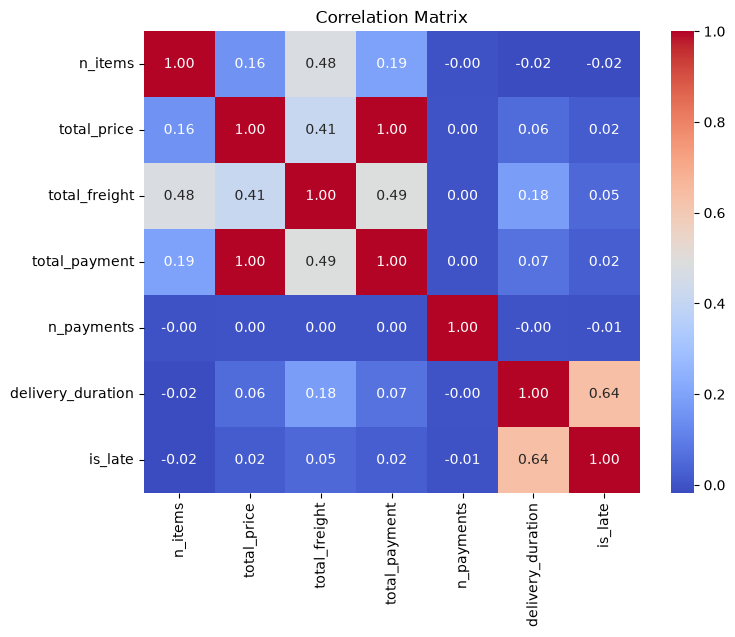

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Correlation Matrix للأعمدة الرقمية

- `delivery_duration` مقابل `is_late` = **0.64** (أقوى ارتباط بالجدول بالكامل) — تأكيد رياضي قوي لتحذير الـ data leakage السابق.  
  `delivery_duration` يجب استبعاده قطعيًا من features Notebook 5.

### Multicollinearity

- `total_price` مقابل `total_payment` = **0.996** (شبه تام) — العمودين يحملان تقريبًا نفس المعلومة (`total_payment ≈ total_price + الشحن`).  
  لـ Notebook 5: استخدام واحد منهم بس.

- `total_freight` مقابل `n_items` = **0.48** (ارتباط متوسط منطقي) — كل ما زاد عدد المنتجات، زادت تكلفة الشحن الإجمالية.

### ارتباطات ضعيفة مع `is_late` (باقي الأعمدة)

- `total_price`: 0.021 | `total_freight`: 0.047 | `n_items`: -0.016 | `n_payments`: -0.006

- كلها ارتباطات ضعيفة جدًا — تؤكد إنو لا يوجد عمود رقمي (غير `delivery_duration` المسرب) عنده تأثير خطي قوي مباشر على التأخير.  
  الفروقات البسيطة اللي شفناها بـ groupby سابقًا صغيرة فعليًا.

------------------------------------------------------------------------------------------------------------------------------------------

### بيانات البائع (`sellers`) — تأجيل متعمد

### الوضع الحالي

بـ Notebook 1، دمجنا `orders` مع `items_agg`, `payments_agg`, و`customers` بس — بدون `sellers`. يعني حاليًا ما فينا نعرف مين باع كل طلبية ولا وين موقع البائع.

### ليش ما دمجناها هسه؟

1. بيانات `sellers` مرتبطة بجدول `order_items` (عبر `seller_id`) مش بجدول `orders` مباشرة. الطلبية ممكن يكون فيها أكتر من بائع (لو فيها منتجات من بائعين مختلفين)، فدمجها يحتاج نفس منطق الـ aggregation يلي عملناه مع `order_items`/`payments` — مش مجرد إضافة عمود بسيط.

2. لازم قرار تصميمي: بطلبية فيها أكتر من بائع، شو "الولاية" يلي نعتمدها؟ الأولى؟ الأكتر تكرار؟ أو نعمل عمود "عدد البائعين بالطلبية"؟ هاد قرار معقد نسبيًا.

3. دمجها هسه كان بيعني إعادة بناء جزء من منطق Notebook 1، وبعدها إعادة تشغيل 1→2→3→4 بالكامل (مرة تالتة بعد التعديل السابق لفلتر `canceled`) — تكلفة وقت وتعقيد غير ضرورية بمرحلة EDA.

### القرار

بيانات البائع أنسب لمرحلة **Feature Engineering (Notebook 5)** وليس استكشاف EDA عام — لأنها فعليًا "بناء feature جديد" أكتر من كونها "فهم البيانات الموجودة".

القرار: توثيقها هون كـ **known limitation** بـ Notebook 4، ومعالجتها بشكل مركّز وصحيح وقت بناء الـ features الفعلية بـ Notebook 5.

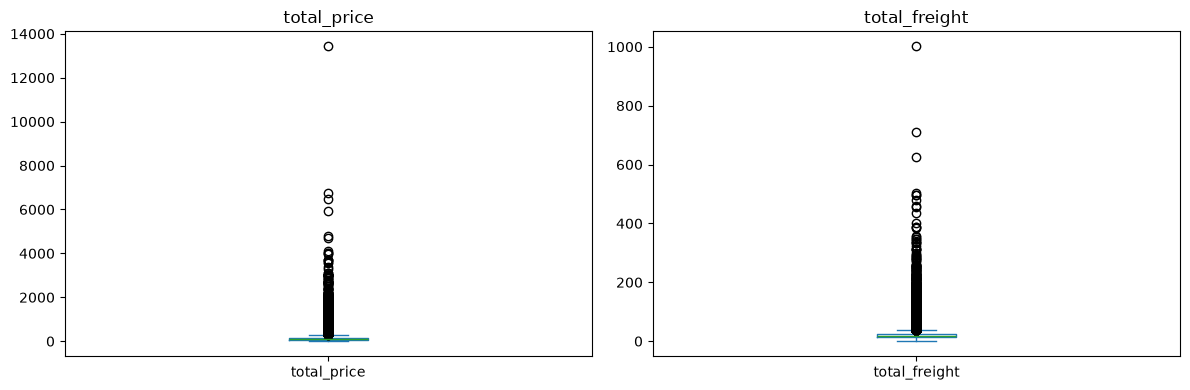

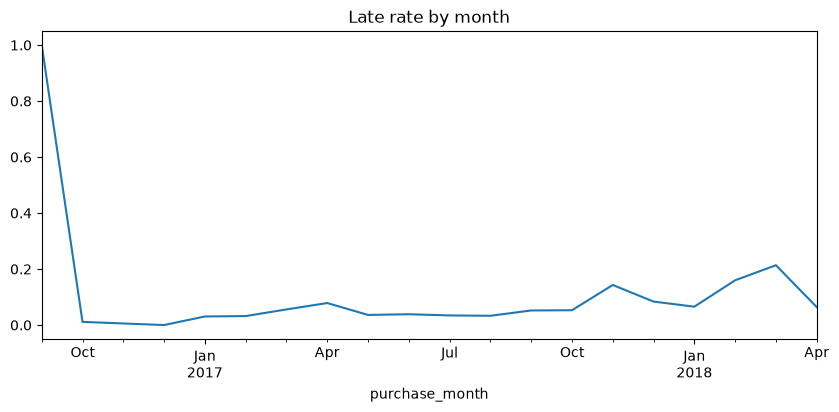

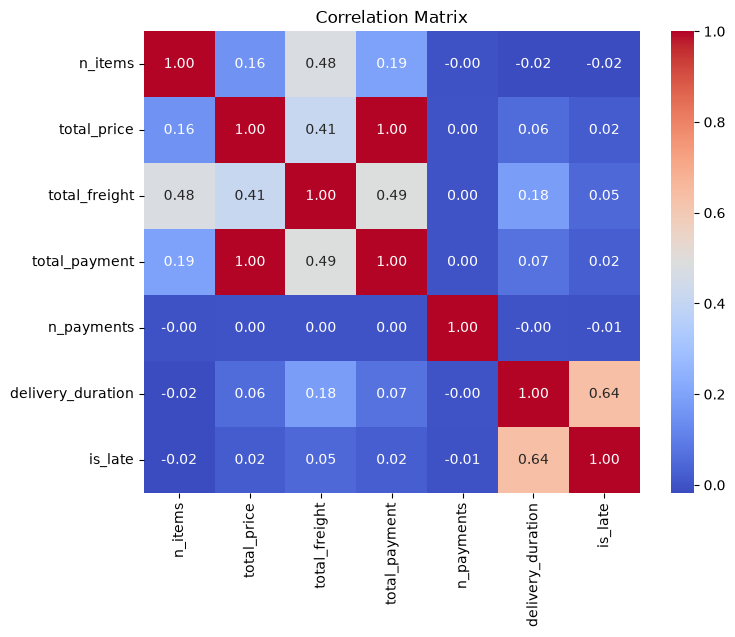

In [ ]:
import os
os.makedirs("data/charts", exist_ok=True)

# Boxplots للـ outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train["total_price"].plot(kind="box", ax=axes[0], title="total_price")
train["total_freight"].plot(kind="box", ax=axes[1], title="total_freight")
plt.tight_layout()
plt.savefig("data/charts/notebook4_outliers_boxplot.png")
plt.show()

# نسبة التأخير الشهرية
train.groupby("purchase_month")["is_late"].mean().plot(kind="line", figsize=(10, 4), title="Late rate by month")
plt.savefig("data/charts/notebook4_late_rate_by_month.png")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig("data/charts/notebook4_correlation_matrix.png")
plt.show()

# Notebook 4 — EDA Findings Summary

## 1. Data Overview & Column Classification
- Analysis was performed on the training split (67,529 rows) — val and test were never opened.
- Columns classified by role:
  - **ID columns** (not used as features): order_id, customer_id, customer_unique_id
  - **Categorical features**: customer_state, customer_city
  - **Numeric features**: n_items, total_price, total_freight, total_payment, n_payments
  - **Date columns**: order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date
- Missing values are very few (less than 0.03%) in columns: order_approved_at (14), order_delivered_carrier_date (1), total_payment (1), n_payments (1) — not concerning, handling decision deferred to Notebook 5.
- Checked whether missingness itself carries signal: orders missing order_approved_at (14 rows) show 0.00% late rate vs. 9.03% overall — but the sample is far too small (14 rows) to draw a reliable conclusion; documented as an exploratory note only, not a strong finding.

## 2. Numerical Columns
- Outliers confirmed (numerically and visually) in total_price (median 85 vs. max 13,440) and total_freight (median 16.79 vs. max 1,002.29).
- Skewness is very high across all numerical columns (all > 1), highest being n_payments (22.42) — supports using log-transformation, RobustScaler, or tree-based models later.
- No negative or illogical values in any numerical column — sanity check passed 100%.

## 3. Categorical Columns
- customer_city (3,747 unique values): spot-checked the first 20 alphabetically — formatting is clean and consistent (lowercase, no duplicate variants like "sao paulo" vs. "Sao Paulo"). This was a quick visual sample, not an exhaustive check of all 3,747 values.
- Rare categories in customer_state (e.g., RR with only 29 rows, AP with 51, AC with 66) — late rates computed on such small samples may be statistically unreliable; small categories should be grouped into an "Other" category in Notebook 5.

## 4. Relationship with the Label
- Late orders have a higher average total_price (149.79 vs. 134.51) and higher average total_freight (25.20 vs. 21.95) — but the linear (Pearson) correlation is very weak for both (0.021 and 0.047 respectively).
- Correlation matrix: no numerical column (other than delivery_duration) has a strong direct linear correlation with lateness.
- Strong multicollinearity: total_price and total_payment are correlated at 0.996 (near-perfect) — recommend using only one of them in Notebook 5.
- Explicit crosstab (customer_state × label) confirms the groupby findings: AL has the highest late rate (27.85%), followed by MA (21.53%) and CE (18.25%); AC and AM have the lowest (4.55%, 4.76%) but are also small-sample states.

## 5. Delivery Duration
- Late: mean 34.05 days | On-time: mean 11.30 days — a large, clear difference.
- Correlation with is_late = 0.64 (the strongest correlation in the entire table).
- **Data Leakage Warning:** delivery_duration is calculated from order_delivered_customer_date, the same column used to build the label. It must be strictly excluded from Notebook 5 features — any column built from dates occurring after the purchase moment carries the same risk.

## 6. Time-Based Analysis
- Clear seasonal pattern: Late rate stable (~0-8%) from October 2016 through November 2017, then a gradual rise up to ~22% between December 2017 and March 2018.
- The first two months (September and December 2016) are not statistically representative (n=1 each) — a "bootstrap" period at the start of data collection, not reflective of actual behavior.
- Day-of-week effect is relatively weak (only ~1.7 percentage point difference between the highest and lowest day) — a low-priority factor for feature engineering.
- Holiday season effect (November–December) is notably stronger: 11.76% late rate vs. 8.39% for the rest of the year (~3.4 percentage point gap) — consistent with the seasonal rise observed above, likely driven by Black Friday/Christmas order volume. This makes purchase_month/is_holiday_season a higher-priority feature than day-of-week.

## 7. Geographic Analysis
- Large differences in late rate across states: AL (27.9%), MA (21.5%), CE (18.2%) — far above the overall average (~9%). Clear geographic pattern: states farther from logistics hubs (northern/northeastern Brazil) have the highest lateness.
- customer_zip_code_prefix is impractical as a direct feature (13,748 unique values) — recommended to use it as a source for geographic coordinates or to group it into broader regions.
- Seller data is not yet merged — a known limitation, intentionally deferred to Notebook 5 since it requires additional aggregation (orders can have multiple sellers) and design decisions.

## 8. Data Issue Discovery and Resolution: order_status
- Discovered 6 orders (0.009%) with "canceled" status that nonetheless have an actual delivery date — a logical inconsistency that makes their label unreliable.
- Went back to Notebook 2 and added a filter to exclude canceled orders before building the label, then re-ran Notebook 2 → 3 → 4 in full (artifact-based flow).
- Later confirmed: order_status is now a single value ("delivered") across the entire training split.

## 9. Overall Summary for Feature Engineering (Notebook 5)
**Promising features:**
- Geographic location (customer_state, with rare categories grouped)
- Time-based variables (month / seasonality / is_holiday_season)
- total_freight, total_price (choose one of price/payment)

**Must be excluded entirely (Data Leakage):**
- delivery_duration and any other column built from dates occurring after the purchase moment

**Need additional processing:**
- Log-transformation or RobustScaler for high-skew columns
- Merging sellers data (deferred and planned)
- Grouping rare geographic categories
- Handling small missing-value groups (order_approved_at, etc.)